In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## 1. Load Dataset

In [2]:
data = []
labels = []
file_name = []

path_dataset = "archive/tomato/train/"

target_classes = [
    "Tomato___Early_blight",
    "Tomato___Septoria_leaf_spot",
    "Tomato___healthy"
]

for sub_folder in target_classes:
    path_sub_folder = os.path.join(path_dataset, sub_folder)
    sub_folder_files = os.listdir(path_sub_folder)[:100]

    for filename in sub_folder_files:
        img_path = os.path.join(path_sub_folder, filename)
        img = cv.imread(img_path)

        if img is not None:
            img = img.astype(np.uint8)
            data.append(img)
            labels.append(sub_folder)
            file_name.append(filename)

data = np.array(data, dtype=object)
labels = np.array(labels)
print(f"Total gambar dimuat: {len(data)}")

Total gambar dimuat: 300


## 2. Fungsi-Fungsi Preprocessing

In [3]:
# === FILTER (mean / median / modus) ===
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    region_flat = np.sort(region.ravel())
                    canvas[i, j] = region_flat[(size * size) // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        count[val] = count.get(val, 0) + 1
                    canvas[i, j] = max(count, key=count.get)

    return canvas


# === DILASI & EROSI (untuk Gradient Morph) ===
def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
    return hasil


def erosi(citra, mask):
    pad_t, pad_l = mask.shape[0] // 2, mask.shape[1] // 2
    citra_pad = np.pad(citra, ((pad_t, pad_t), (pad_l, pad_l)),
                       mode='constant', constant_values=255)
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for r in range(pad_t, citra_pad.shape[0] - pad_t):
        for c in range(pad_l, citra_pad.shape[1] - pad_l):
            blok = citra_pad[r-pad_t:r+pad_t+1, c-pad_l:c+pad_l+1]
            if np.all(blok[mask == 1] == 255):
                hasil[r-pad_t, c-pad_l] = 255
    return hasil


# === GRADIENT MORPH = Dilasi - Erosi ===
def gradient_morph(img, kernel):
    img_uint8 = img.astype(np.uint8)
    hasil_dilasi = dilasi(img_uint8, kernel).astype(np.float32)
    hasil_erosi  = erosi(img_uint8, kernel).astype(np.float32)
    gradien = hasil_dilasi - hasil_erosi
    gradien = np.clip(gradien, 0, 255).astype(np.uint8)
    return gradien


# Kernel morfologi 3x3
kernel_morph = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

print("Fungsi preprocessing siap!")

Fungsi preprocessing siap!


In [4]:
def preprocessing_percobaan3(img_bgr):
    """
    Alur Percobaan 3:
    1. Threshold channel 2 warna (Saturation HSV) → hapus background
    2. Masking pertama → isolasi daun dari background
    3. Gradient Morph → dari grayscale hasil masking pertama
    4. Threshold channel Green → hapus area penyakit
    5. Masking kedua → ambil hanya daun hijau bersih
    6. Grayscale
    7. Timpa dengan Gradient Morph
    """
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
    tinggi, lebar = img_rgb.shape[:2]

    # -------------------------------------------------------
    # STEP 1: Threshold channel Saturation (hapus background)
    # Background abu-abu/gelap → Saturation rendah
    # Daun & penyakit → Saturation tinggi
    # -------------------------------------------------------
    mask_bg = np.zeros((tinggi, lebar), dtype=np.uint8)
    for i in range(tinggi):
        for j in range(lebar):
            sat = int(img_hsv[i, j, 1])
            if sat > 35:        # piksel warna pekat = daun/penyakit
                mask_bg[i, j] = 255
            else:
                mask_bg[i, j] = 0

    mask_bg_clean = filter(mask_bg, 5, 'median')

    # -------------------------------------------------------
    # STEP 2: Masking pertama → isolasi daun dari background
    # -------------------------------------------------------
    daun_masked1 = np.zeros((tinggi, lebar, 3), dtype=np.uint8)
    for i in range(tinggi):
        for j in range(lebar):
            if mask_bg_clean[i, j] == 255:
                daun_masked1[i, j] = img_rgb[i, j]
            else:
                daun_masked1[i, j] = [0, 0, 0]

    # -------------------------------------------------------
    # STEP 3: Gradient Morph → dari grayscale hasil masking pertama
    # -------------------------------------------------------
    daun_gray_step3 = cv.cvtColor(daun_masked1, cv.COLOR_RGB2GRAY)
    grad_morph = gradient_morph(daun_gray_step3, kernel_morph)

    # -------------------------------------------------------
    # STEP 4: Threshold channel Green → hapus area penyakit
    # Penyakit (coklat/kuning) → G tidak jauh lebih besar dari R
    # Daun sehat (hijau) → G dominan terhadap R dan B
    # -------------------------------------------------------
    mask_green = np.zeros((tinggi, lebar), dtype=np.uint8)
    for i in range(tinggi):
        for j in range(lebar):
            r = int(daun_masked1[i, j, 0])
            g = int(daun_masked1[i, j, 1])
            b = int(daun_masked1[i, j, 2])

            # Ambil area hijau saja (daun sehat)
            # g harus dominan terhadap R dan B
            if (g > r + 10) and (g > b + 10):
                mask_green[i, j] = 255
            else:
                mask_green[i, j] = 0

    mask_green_clean = filter(mask_green, 5, 'median')

    # -------------------------------------------------------
    # STEP 5: Masking kedua → ambil hanya area hijau (bersih)
    # -------------------------------------------------------
    daun_masked2 = np.zeros((tinggi, lebar, 3), dtype=np.uint8)
    for i in range(tinggi):
        for j in range(lebar):
            if mask_green_clean[i, j] == 255:
                daun_masked2[i, j] = daun_masked1[i, j]
            else:
                daun_masked2[i, j] = [0, 0, 0]

    # -------------------------------------------------------
    # STEP 6: Grayscale
    # -------------------------------------------------------
    daun_gray_final = cv.cvtColor(daun_masked2, cv.COLOR_RGB2GRAY)

    # -------------------------------------------------------
    # STEP 7: Timpa dengan Gradient Morph
    # Tambahkan kembali informasi tepi dari gradient morph
    # -------------------------------------------------------
    hasil_akhir = np.clip(
        daun_gray_final.astype(np.int32) + grad_morph.astype(np.int32),
        0, 255
    ).astype(np.uint8)

    return (
        mask_bg_clean,
        daun_masked1,
        grad_morph,
        mask_green_clean,
        daun_masked2,
        daun_gray_final,
        hasil_akhir
    )

print("Fungsi pipeline percobaan 3 siap!")

Fungsi pipeline percobaan 3 siap!


## 4. Visualisasi Pipeline pada Sample Gambar

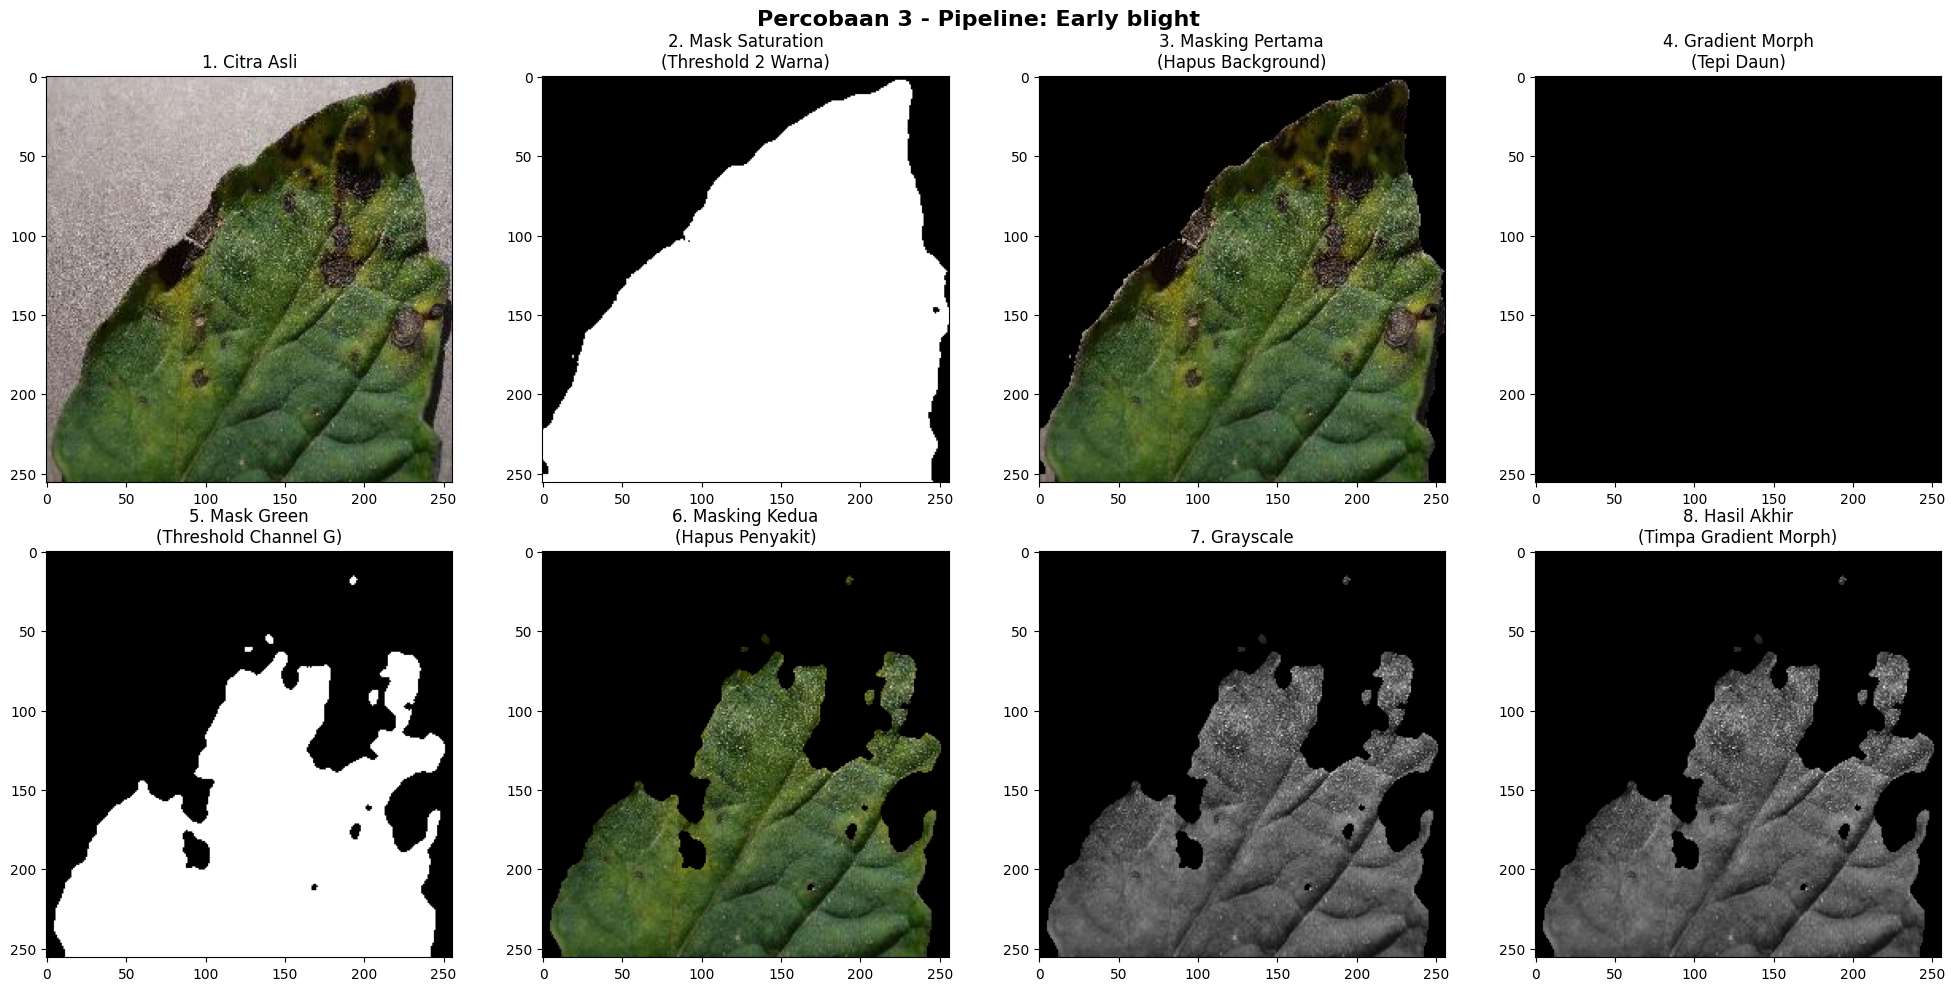

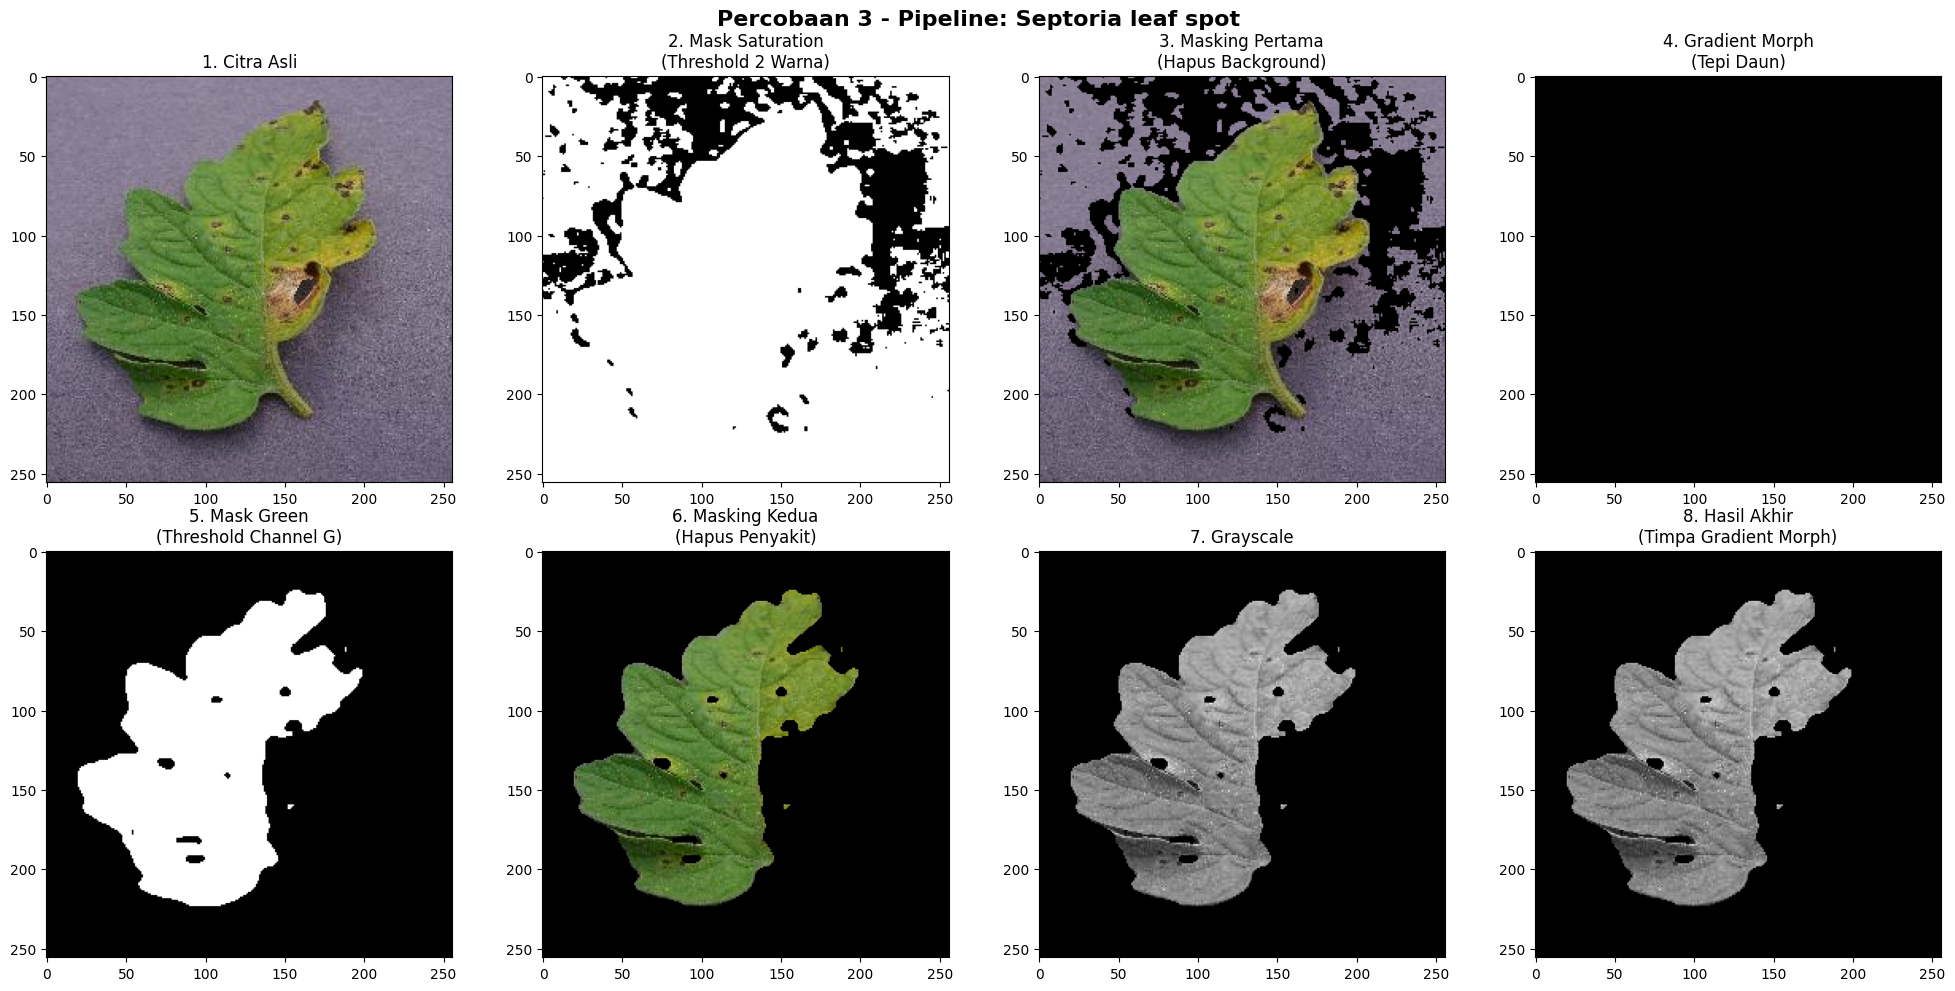

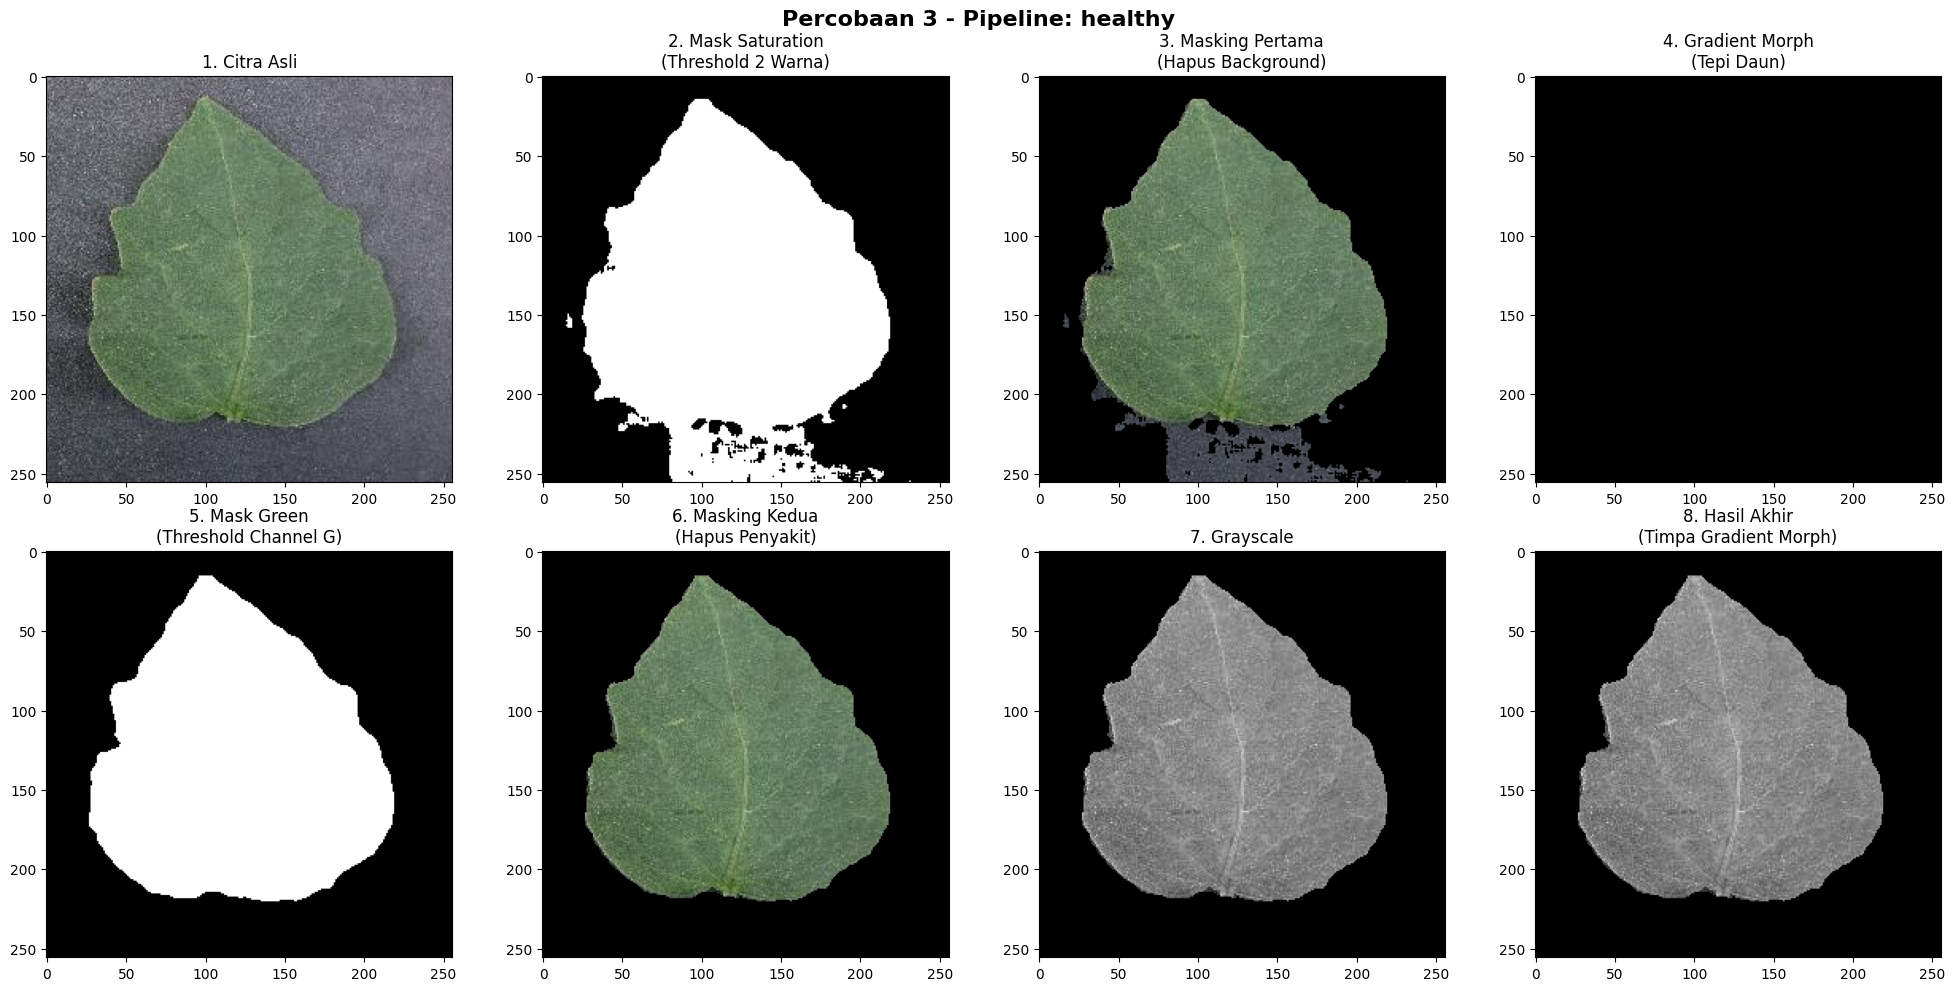

In [5]:
for nama_kelas in target_classes:
    indeks_kelas = [idx for idx, lbl in enumerate(labels) if lbl == nama_kelas]
    idx_sample = indeks_kelas[0]  # Ambil 1 gambar sebagai sample

    img_sample = data[idx_sample].astype(np.uint8)
    img_rgb_sample = cv.cvtColor(img_sample, cv.COLOR_BGR2RGB)

    mask_bg, daun_masked1, grad_morph, mask_green, daun_masked2, daun_gray, hasil_akhir = \
        preprocessing_percobaan3(img_sample)

    judul_bersih = nama_kelas.replace("Tomato___", "").replace("_", " ")

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(f'Percobaan 3 - Pipeline: {judul_bersih}', fontsize=16, fontweight='bold')

    axes[0, 0].imshow(img_rgb_sample)
    axes[0, 0].set_title('1. Citra Asli')
    axes[0, 0].axis('on')

    axes[0, 1].imshow(mask_bg, cmap='gray')
    axes[0, 1].set_title('2. Mask Saturation\n(Threshold 2 Warna)')
    axes[0, 1].axis('on')

    axes[0, 2].imshow(daun_masked1)
    axes[0, 2].set_title('3. Masking Pertama\n(Hapus Background)')
    axes[0, 2].axis('on')

    axes[0, 3].imshow(grad_morph, cmap='gray')
    axes[0, 3].set_title('4. Gradient Morph\n(Tepi Daun)')
    axes[0, 3].axis('on')

    axes[1, 0].imshow(mask_green, cmap='gray')
    axes[1, 0].set_title('5. Mask Green\n(Threshold Channel G)')
    axes[1, 0].axis('on')

    axes[1, 1].imshow(daun_masked2)
    axes[1, 1].set_title('6. Masking Kedua\n(Hapus Penyakit)')
    axes[1, 1].axis('on')

    axes[1, 2].imshow(daun_gray, cmap='gray')
    axes[1, 2].set_title('7. Grayscale')
    axes[1, 2].axis('on')

    axes[1, 3].imshow(hasil_akhir, cmap='gray')
    axes[1, 3].set_title('8. Hasil Akhir\n(Timpa Gradient Morph)')
    axes[1, 3].axis('on')

    plt.tight_layout()
    plt.show()

## 5. Preprocessing Seluruh Dataset

In [6]:
data_p3 = []

print("Memulai preprocessing percobaan 3...")

for i in range(len(data)):
    img_bgr = data[i].astype(np.uint8)
    _, _, _, _, _, _, hasil_akhir = preprocessing_percobaan3(img_bgr)
    data_p3.append(hasil_akhir)

    if (i + 1) % 50 == 0:
        print(f"  Selesai: {i+1}/{len(data)} gambar")

data_p3 = np.array(data_p3, dtype=object)
print(f"\nPreprocessing selesai! Total: {len(data_p3)} gambar")

Memulai preprocessing percobaan 3...
  Selesai: 50/300 gambar
  Selesai: 100/300 gambar
  Selesai: 150/300 gambar
  Selesai: 200/300 gambar
  Selesai: 250/300 gambar
  Selesai: 300/300 gambar

Preprocessing selesai! Total: 300 gambar


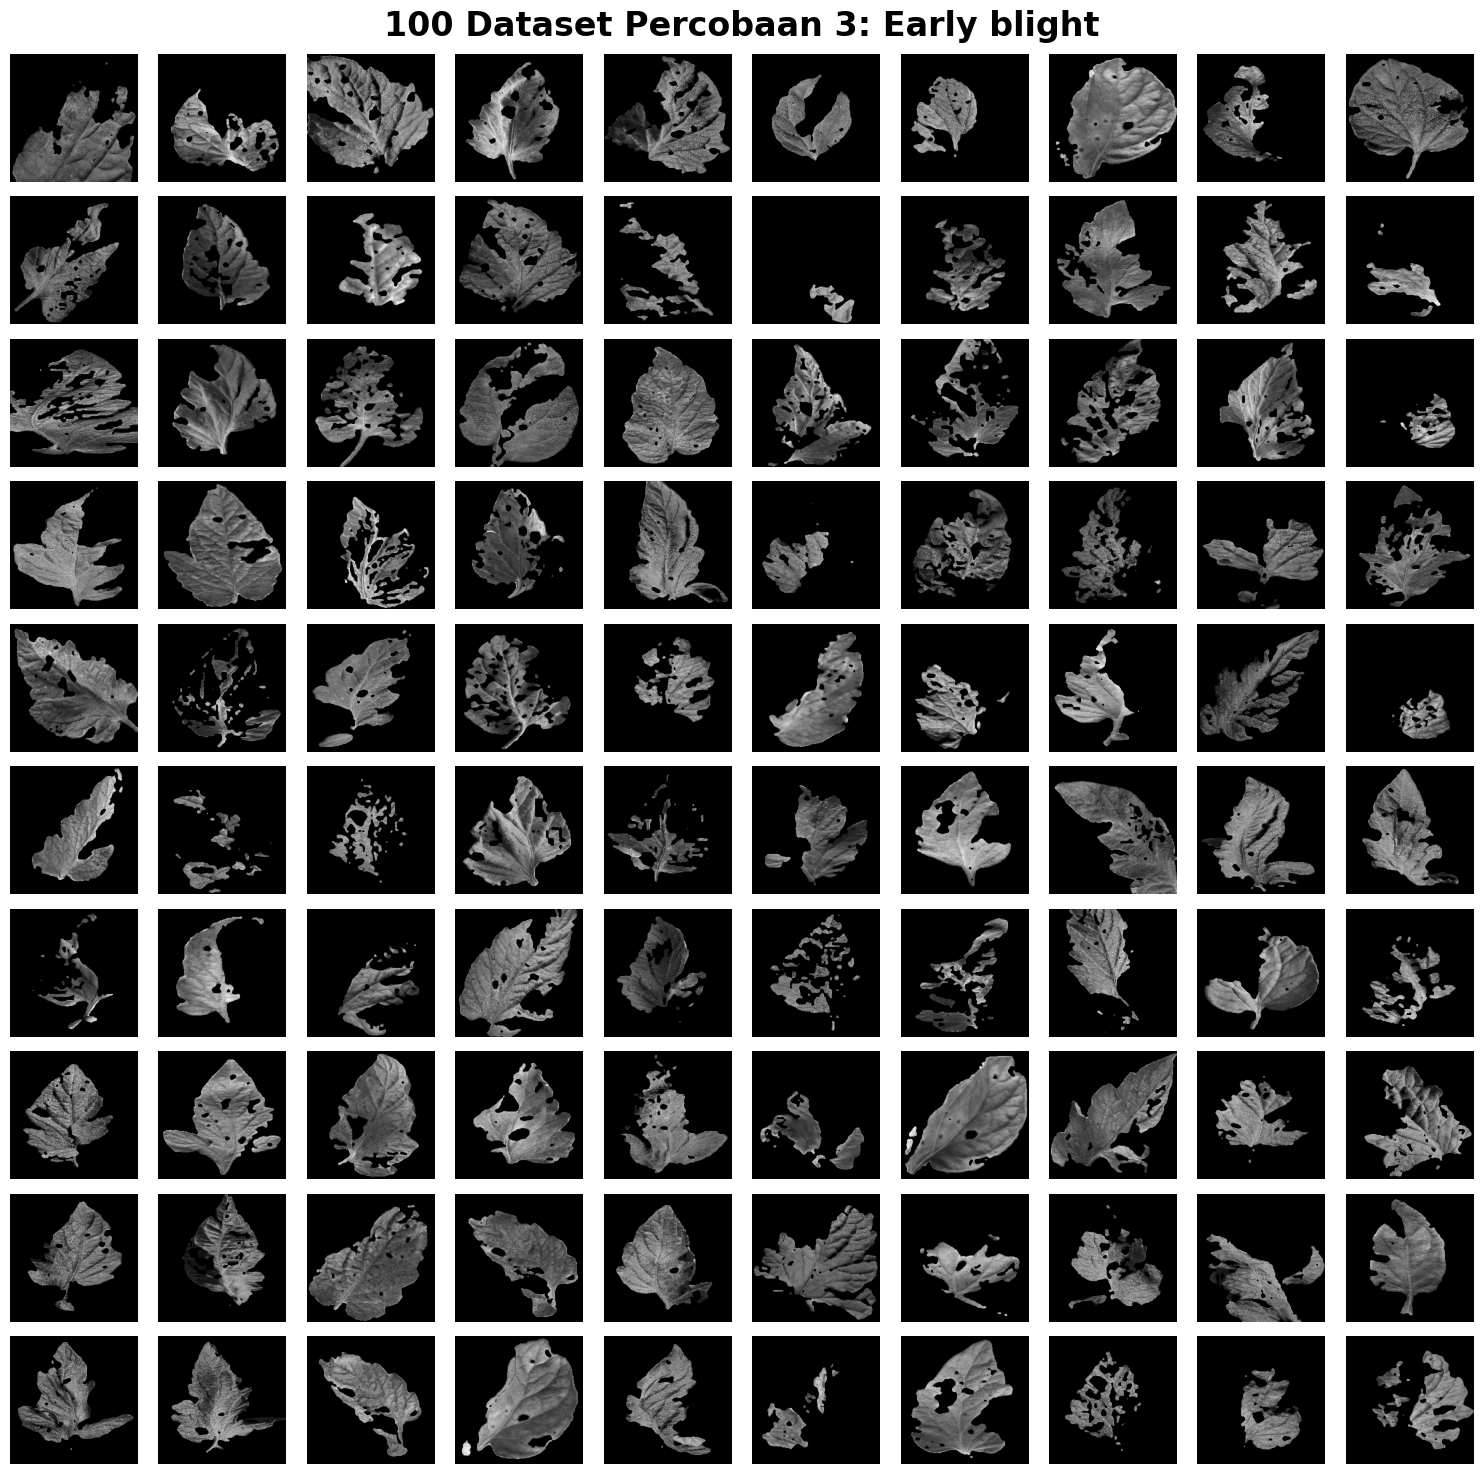

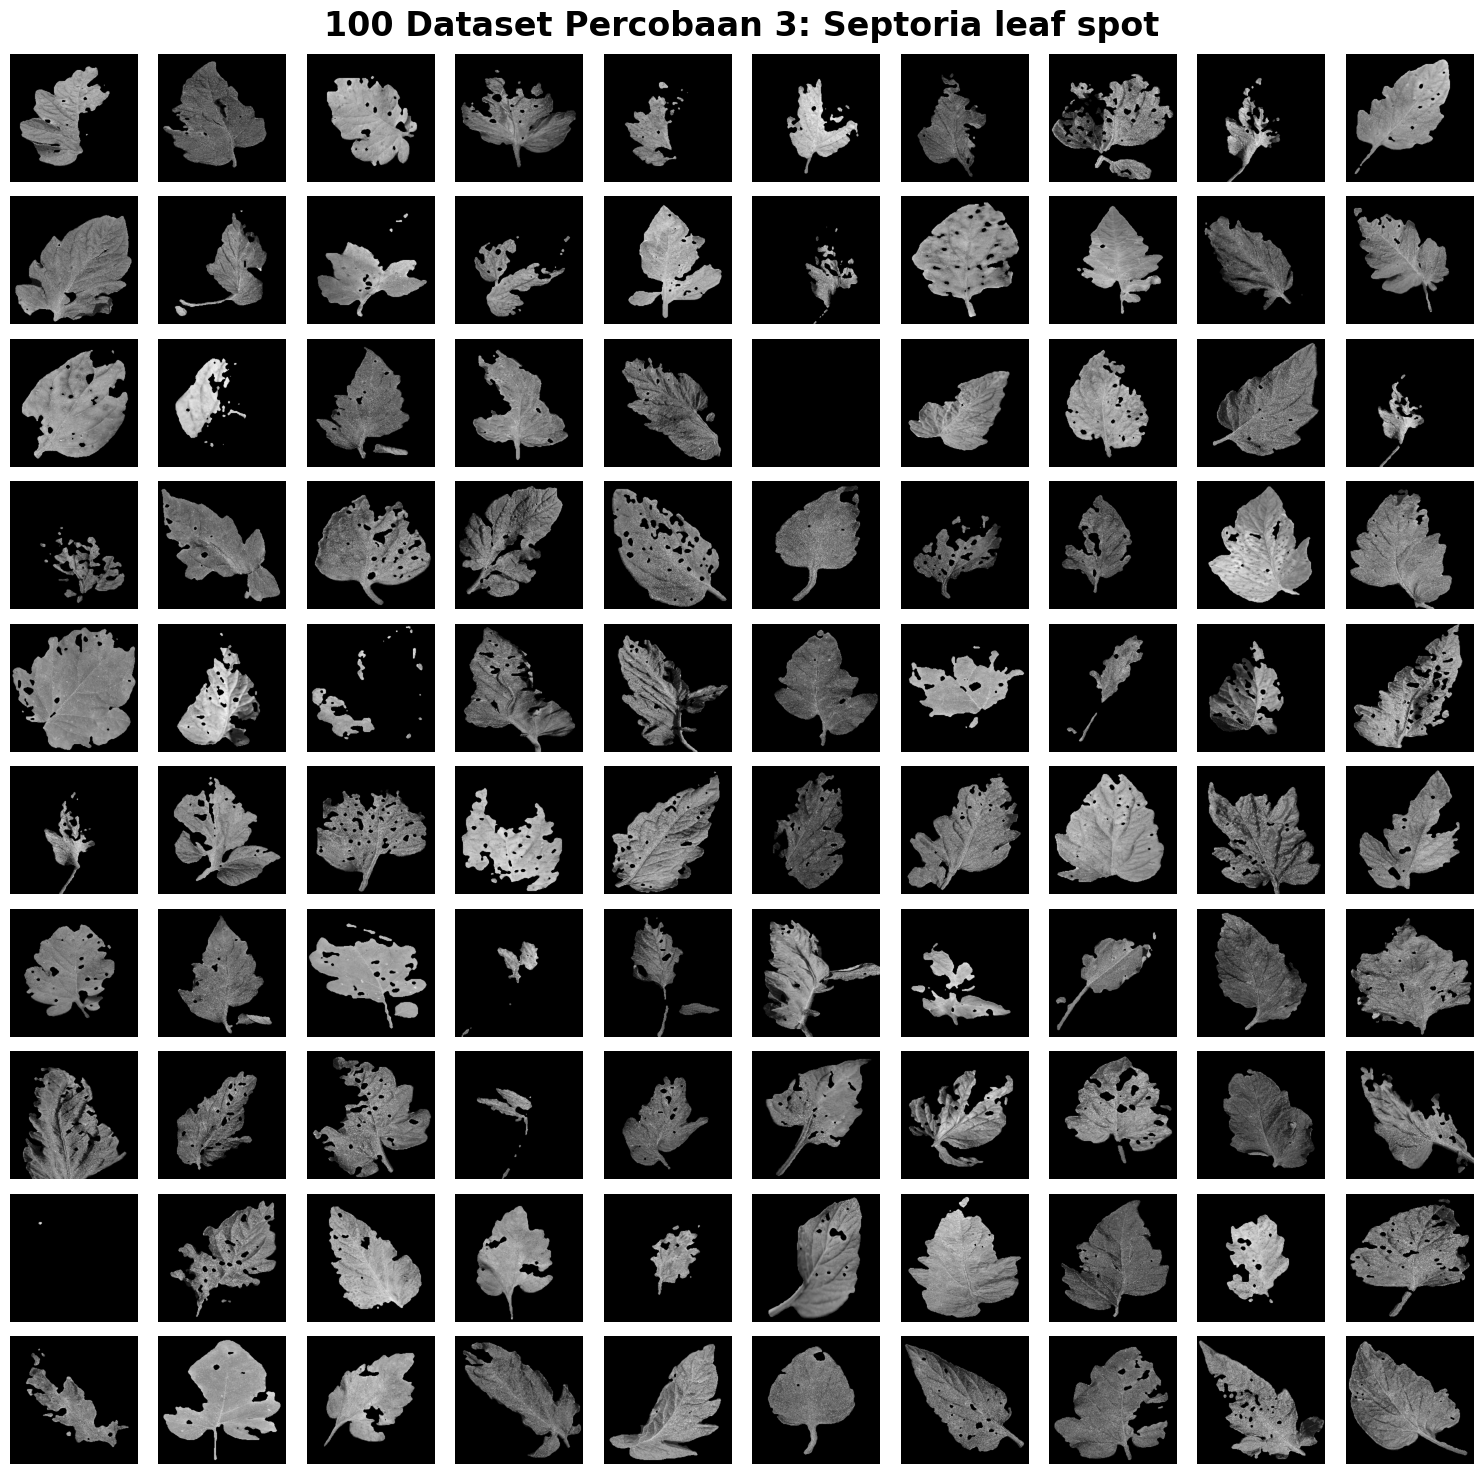

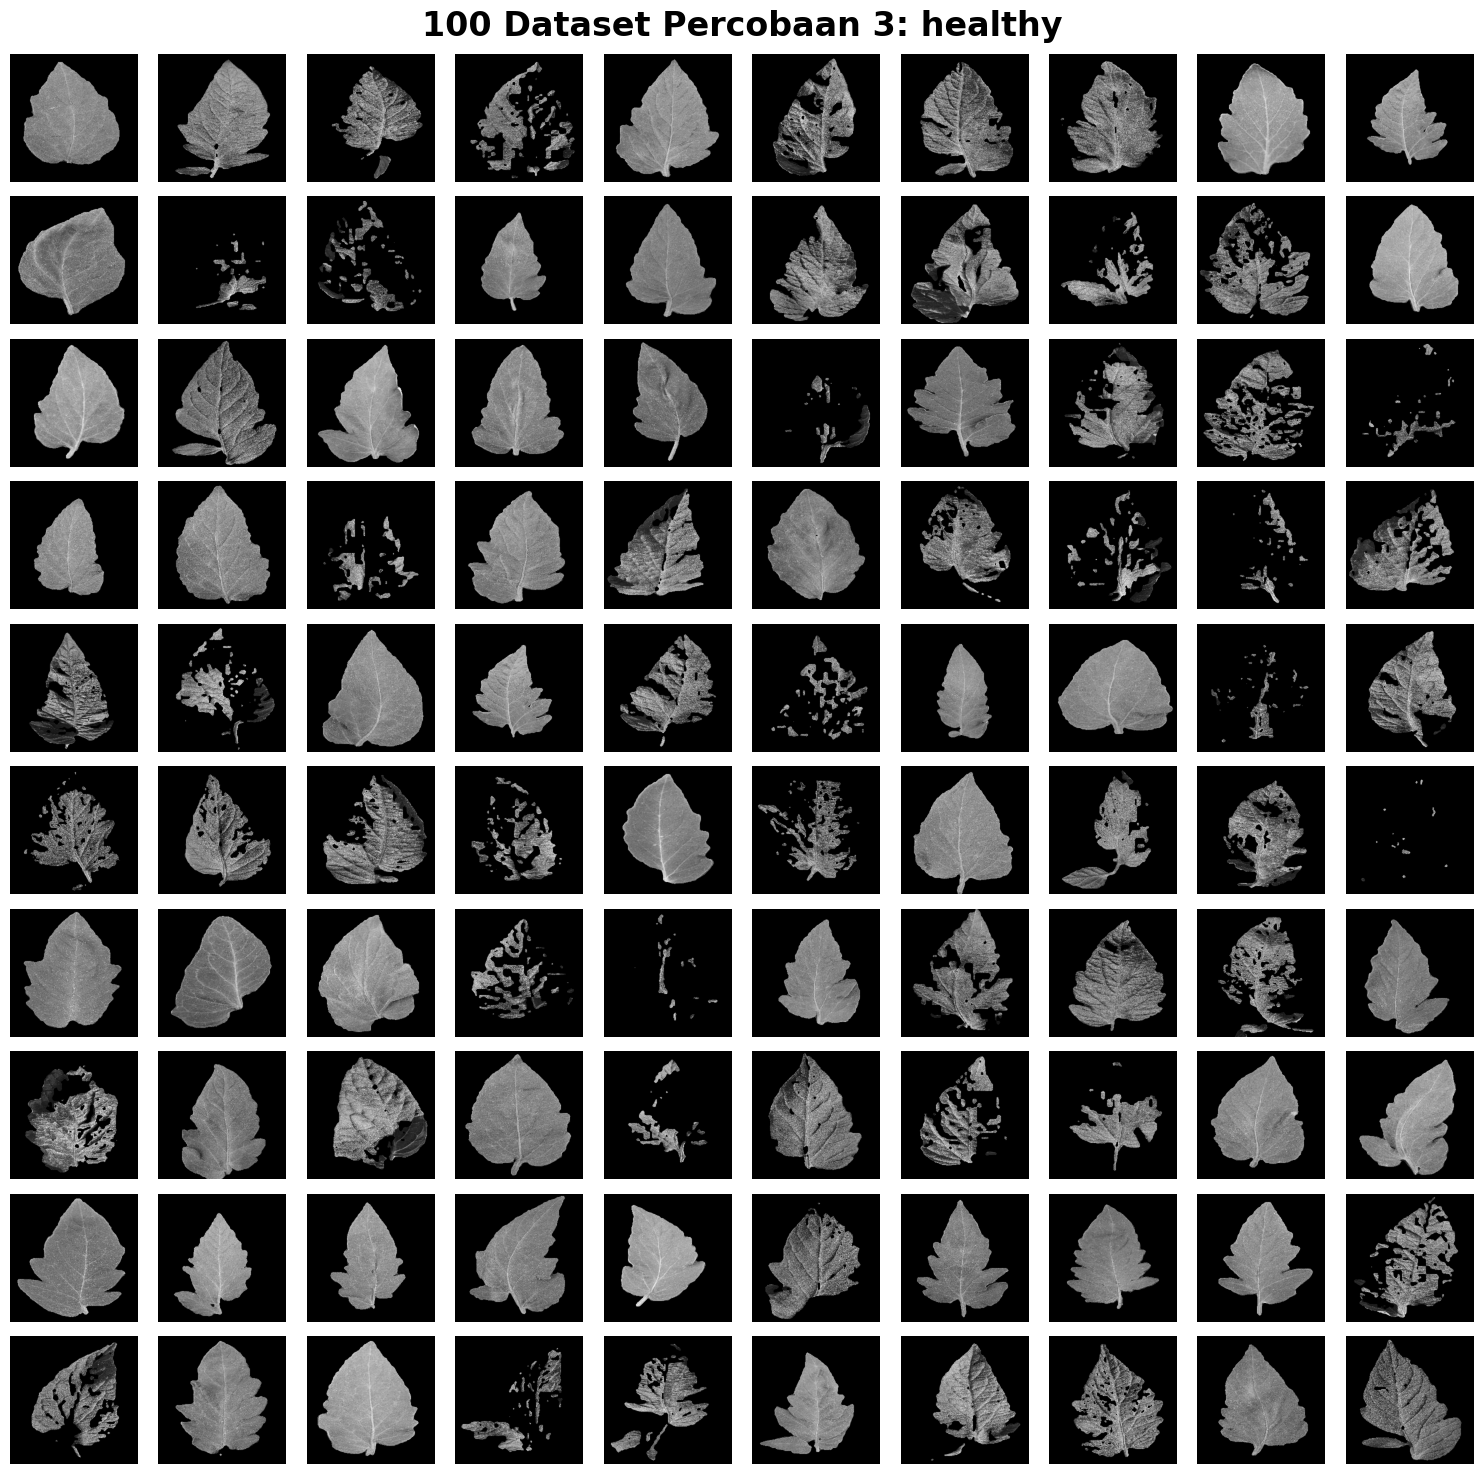

In [7]:
for nama_kelas in target_classes:
    indeks_kelas = [idx for idx, lbl in enumerate(labels) if lbl == nama_kelas]

    fig, axes = plt.subplots(10, 10, figsize=(15, 15))
    judul_bersih = nama_kelas.replace("Tomato___", "").replace("_", " ")
    fig.suptitle(f"100 Dataset Percobaan 3: {judul_bersih}", fontsize=24, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i < len(indeks_kelas):
            ax.imshow(data_p3[indeks_kelas[i]].astype(np.uint8), cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

## 7. Ekstraksi Fitur GLCM

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan salah satu: 0, 45, 90, 135.")

    img_safe = image.astype(np.uint8)
    matriks = graycomatrix(img_safe, [1], angles, 256, symmetric=True, normed=True)
    return matriks

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

print("Fungsi GLCM siap!")

Fungsi GLCM siap!


In [9]:
print("Memulai proses Ekstraksi Fitur GLCM...")

dataPreprocessed = data_p3

Derajat0, Derajat45, Derajat90, Derajat135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Derajat0.append(glcm(dataPreprocessed[i], 0))
    Derajat45.append(glcm(dataPreprocessed[i], 45))
    Derajat90.append(glcm(dataPreprocessed[i], 90))
    Derajat135.append(glcm(dataPreprocessed[i], 135))

Kontras0, Kontras45, Kontras90, Kontras135           = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135           = [], [], [], []
ASM0, ASM45, ASM90, ASM135                           = [], [], [], []
energy0, energy45, energy90, energy135               = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

dataTable = {
    'Filename': file_name,
    'Label': labels,
    'Contrast0': Kontras0,         'Contrast45': Kontras45,
    'Contrast90': Kontras90,       'Contrast135': Kontras135,
    'Homogeneity0': homogenity0,   'Homogeneity45': homogenity45,
    'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0,  'Dissimilarity45': dissimilarity45,
    'Dissimilarity90': dissimilarity90,'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0,          'Entropy45': entropy45,
    'Entropy90': entropy90,        'Entropy135': entropy135,
    'ASM0': ASM0,                  'ASM45': ASM45,
    'ASM90': ASM90,                'ASM135': ASM135,
    'Energy0': energy0,            'Energy45': energy45,
    'Energy90': energy90,          'Energy135': energy135,
    'Correlation0': correlation0,  'Correlation45': correlation45,
    'Correlation90': correlation90,'Correlation135': correlation135,
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_p3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_p3.csv')
print("Ekstraksi Fitur Selesai & Disimpan ke hasil_ekstraksi_p3.csv!")
hasilEkstrak

Memulai proses Ekstraksi Fitur GLCM...
Ekstraksi Fitur Selesai & Disimpan ke hasil_ekstraksi_p3.csv!


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly...,Tomato___Early_blight,305.761887,363.727428,276.009038,325.980715,0.587876,0.576996,0.593142,0.581234,...,0.298634,0.294212,0.542827,0.540628,0.546474,0.542413,0.916383,0.900682,0.924548,0.910989
1,0034a551-9512-44e5-ba6c-827f85ecc688___RS_Erly...,Tomato___Early_blight,122.514645,173.447812,124.899449,186.761615,0.780422,0.760553,0.767849,0.760137,...,0.541873,0.536107,0.735743,0.732347,0.736120,0.732193,0.955404,0.937036,0.954535,0.932203
2,004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly...,Tomato___Early_blight,757.874985,885.632741,750.062960,917.957816,0.483975,0.473610,0.483125,0.471626,...,0.197929,0.193051,0.446622,0.441267,0.444893,0.439376,0.904834,0.888827,0.905818,0.884769
3,0114f7b3-7f56-4bef-aa47-7a82da142d4b___RS_Erly...,Tomato___Early_blight,216.210141,269.996002,193.943505,268.097255,0.692955,0.684421,0.693815,0.684327,...,0.442627,0.437842,0.665102,0.661143,0.665302,0.661697,0.949878,0.937560,0.955040,0.937999
4,011aa278-a39e-40b0-b6e4-2e2f835889f0___RS_Erly...,Tomato___Early_blight,559.666299,679.235679,602.132506,670.448258,0.590499,0.579245,0.587877,0.577930,...,0.308825,0.303679,0.556748,0.550825,0.555721,0.551070,0.902742,0.882165,0.895363,0.883690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,291a778d-bfbd-450e-98a8-d8276a9a5cf2___GH_HL L...,Tomato___healthy,183.169455,234.898977,177.747365,244.961968,0.731426,0.721059,0.729628,0.720929,...,0.484676,0.480772,0.696371,0.693562,0.696186,0.693377,0.969442,0.960902,0.970347,0.959227
296,29265f8d-86ff-4de1-b1ad-e33a64b189dc___RS_HL 0...,Tomato___healthy,746.621507,938.460592,814.280300,829.450765,0.693693,0.689016,0.692816,0.690290,...,0.467370,0.463203,0.683339,0.679929,0.683645,0.680590,0.904833,0.880672,0.896208,0.894533
297,29289230-4809-46cd-ba98-77af06af3f32___RS_HL 9...,Tomato___healthy,1218.050582,1408.404152,1244.687745,1387.750804,0.657071,0.650669,0.655653,0.650629,...,0.418932,0.412469,0.647893,0.642238,0.647250,0.642238,0.837474,0.812496,0.833919,0.815246
298,293dddf9-f5e5-42de-ab68-f1cad0f69a43___GH_HL L...,Tomato___healthy,288.474326,334.614441,277.296415,347.684491,0.655226,0.649984,0.654741,0.650430,...,0.398785,0.394890,0.631265,0.628880,0.631494,0.628403,0.959524,0.953132,0.961092,0.951301


## 8. Seleksi Fitur & Heatmap Korelasi

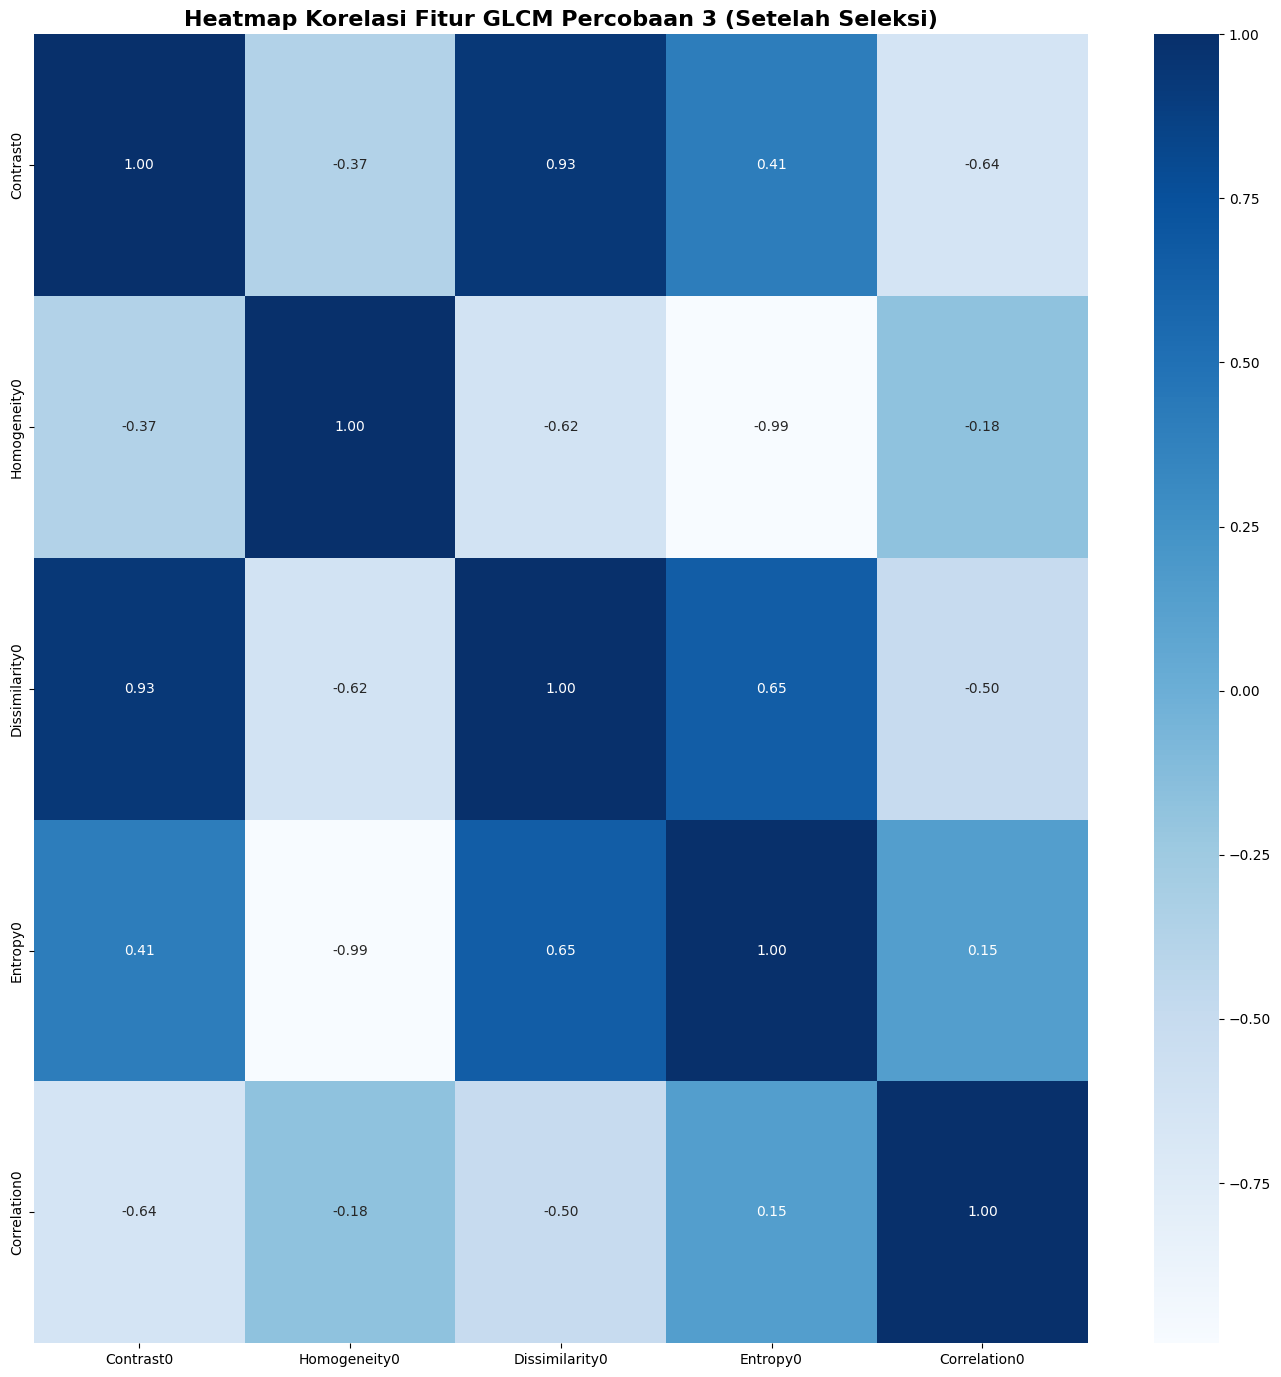

Jumlah fitur setelah seleksi: 5


,Contrast0,Homogeneity0,Dissimilarity0,Entropy0,Correlation0
0,305.761887,0.587876,7.355331,4.616396,0.916383
1,122.514645,0.780422,2.723009,2.721836,0.955404
2,757.874985,0.483975,13.366406,5.923901,0.904834
3,216.210141,0.692955,5.497886,3.656795,0.949878
4,559.666299,0.590499,10.520650,4.840408,0.902742
...,...,...,...,...,...
295,183.169455,0.731426,4.166636,3.062607,0.969442
296,746.621507,0.693693,11.463725,3.702115,0.904833
297,1218.050582,0.657071,15.682966,4.096938,0.837474
298,288.474326,0.655226,6.781893,3.795666,0.959524


In [10]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i, j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

plt.figure(figsize=(17, 17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur GLCM Percobaan 3 (Setelah Seleksi)', fontsize=16, fontweight='bold')
plt.show()

print(f"Jumlah fitur setelah seleksi: {x_new.shape[1]}")
x_new

## 9. Split Data & Normalisasi

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Testing set : {X_test.shape}")

# Normalisasi mean-std
train_mean = X_train.mean()
train_std  = X_train.std()

X_train = (X_train - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

Training set: (240, 5)
Testing set : (60, 5)


## 10. Klasifikasi

In [12]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Inisialisasi model
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [13]:
# === RANDOM FOREST ===
print("==================================================")
print("              RANDOM FOREST CLASSIFIER            ")
print("==================================================")
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_rf = rf.predict(X_train)
generateClassificationReport(y_train, y_pred_train_rf)

print("\n------Testing Set------")
y_pred_test_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_test_rf)

              RANDOM FOREST CLASSIFIER            
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.91      1.00      0.95        78
Tomato___Septoria_leaf_spot       0.96      0.93      0.95        84
           Tomato___healthy       0.99      0.92      0.95        78

                   accuracy                           0.95       240
                  macro avg       0.95      0.95      0.95       240
               weighted avg       0.95      0.95      0.95       240

[[78  0  0]
 [ 5 78  1]
 [ 3  3 72]]
Accuracy: 0.95

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.65      0.77      0.71        22
Tomato___Septoria_leaf_spot       0.33      0.25      0.29        16
           Tomato___healthy       0.77      0.77      0.77        22

                   accuracy                           0.63        60
              

In [14]:
# === SVM ===
print("==================================================")
print("                   SVM CLASSIFIER                 ")
print("==================================================")
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_svm = svm.predict(X_train)
generateClassificationReport(y_train, y_pred_train_svm)

print("\n------Testing Set------")
y_pred_test_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_test_svm)

                   SVM CLASSIFIER                 
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.70      0.68      0.69        78
Tomato___Septoria_leaf_spot       0.64      0.63      0.63        84
           Tomato___healthy       0.83      0.86      0.84        78

                   accuracy                           0.72       240
                  macro avg       0.72      0.72      0.72       240
               weighted avg       0.72      0.72      0.72       240

[[53 20  5]
 [22 53  9]
 [ 1 10 67]]
Accuracy: 0.7208333333333333

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.80      0.73      0.76        22
Tomato___Septoria_leaf_spot       0.53      0.56      0.55        16
           Tomato___healthy       0.70      0.73      0.71        22

                   accuracy                           0.68        60


In [15]:
# === KNN ===
print("==================================================")
print("                   KNN CLASSIFIER                 ")
print("==================================================")
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred_train_knn = knn.predict(X_train)
generateClassificationReport(y_train, y_pred_train_knn)

print("\n------Testing Set------")
y_pred_test_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_test_knn)

                   KNN CLASSIFIER                 
------Training Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.77      0.79      0.78        78
Tomato___Septoria_leaf_spot       0.71      0.71      0.71        84
           Tomato___healthy       0.88      0.83      0.86        78

                   accuracy                           0.78       240
                  macro avg       0.78      0.78      0.78       240
               weighted avg       0.78      0.78      0.78       240

[[62 14  2]
 [17 60  7]
 [ 2 11 65]]
Accuracy: 0.7791666666666667

------Testing Set------
                             precision    recall  f1-score   support

      Tomato___Early_blight       0.64      0.73      0.68        22
Tomato___Septoria_leaf_spot       0.43      0.38      0.40        16
           Tomato___healthy       0.86      0.82      0.84        22

                   accuracy                           0.67        60


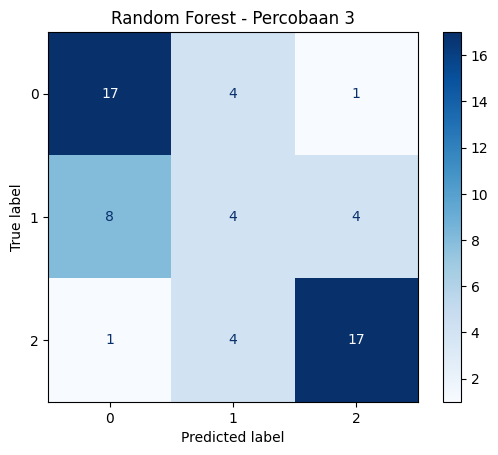

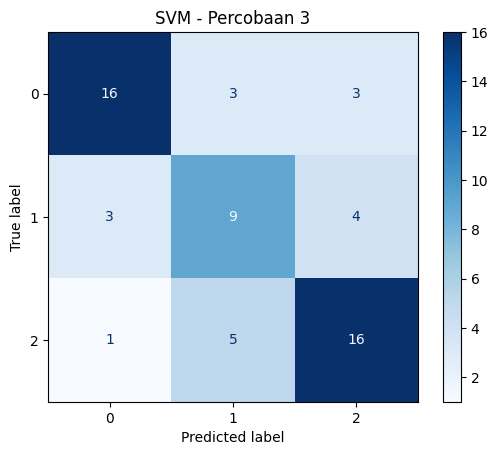

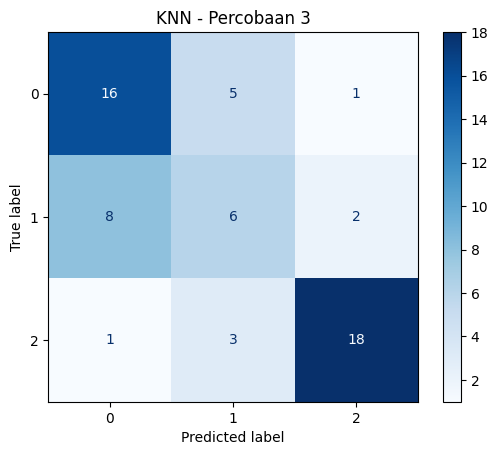

In [16]:
# === CONFUSION MATRIX ===
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest - Percobaan 3")
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM - Percobaan 3")
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN - Percobaan 3")